# Probabilistic Arbitrage: Modeling NBA Scoring Distributions to Identify Inefficiencies in Player Prop Markets

**Authors:** Xuelun Hou and Tudor Popescu

## Abstract

**Objective:**
Our project constructs a systematic quantitative trading strategy by identifying mispriced variance in NBA sportsbook totals. Instead of relying on traditional point-estimate predictions, we model team scoring as a continuous probability distribution to price discrete betting lines to find statistical arbitrage.

**Methodology:**
1. **Data Engineering:** Used multiple seasons of game-level box scores via the NBA API, engineering Exponential Moving Average (EMA) time-series features (Offensive Rating, Defensive Rating, Pace) to capture structural roster changes while strictly preventing look-ahead bias.
2. **Distribution Fitting:** Modeled team scoring utilizing a Negative Binomial distribution. Applied the Method of Moments to dynamically map rolling means and overdispersed variances into distribution parameters, resolving the inherent variance-equals-mean constraints of standard Poisson processes.
3. **Predictive Modeling:** Progressed through a rigorous hierarchy of generalized linear models to generate matchup-adjusted scoring expectations. Evaluated Poisson GLMs, Random Forests, XGBoost, and PyTorch Multi-Layer Perceptrons against a Negative Log-Likelihood (NLL) optimization metric.
4. **Risk Management & Execution:** Applied the Kelly Criterion compute the mathematically optimal size of the bet, and an wrote elastic net to stabilize feature coefficients.

**Conclusion:**
In this project, we use various basketball features to show that while market makers accurately price baseline averages, they systematically misprice the structural volatility of specific matchups. We combined the data analytical tools learned at the Erdős Institute with our probability knowledge, this model successfully extracts positive expected value from statistical noise.

In [ ]:
# Install required packages for the environment
!pip install nba_api xgboost torch scikit-learn statsmodels

## Data Ingestion & Feature Engineering (Time-Decay)

Before modeling, we must establish a clean time series of team scoring. We use the `nba_api` to download game-level box scores for all 30 NBA teams over the last few seasons, and betting lines from the last few seasons (we could only find them until the 22-23 season unfortunately).

To avoid look-ahead bias and capture structural roster changes (such as sudden injuries to star players or mid-season trades), we calculate rolling features for any given game $t$ using the team's historical performance up to game $t-1$. Instead of a Simple Moving Average (SMA), we utilize an **Exponential Moving Average (EMA)**. An EMA mathematically decays the weight of older observations, allowing our expected mean ($\mu$) and variance ($\sigma^2$) to rapidly adapt to abrupt shifts in a team's offensive output.

In [ ]:
import pandas as pd
import numpy as np
import time
import requests
import io
from nba_api.stats.endpoints import teamgamelogs
from requests.exceptions import ReadTimeout, ConnectionError

def fetch_nba_team_data(seasons, max_retries=3):
  #The nba api is weird, we have to try multiple times to get it
    appended_data = []
    for season in seasons:
        print(f"Fetching NBA API data for season: {season}...")
        advanced_logs, basic_logs = None, None
        for attempt in range(max_retries):
            try:
                advanced_logs = teamgamelogs.TeamGameLogs(
                    season_nullable=season, measure_type_player_game_logs_nullable='Advanced', timeout=60
                ).get_data_frames()[0]
                basic_logs = teamgamelogs.TeamGameLogs(
                    season_nullable=season, measure_type_player_game_logs_nullable='Base', timeout=60
                ).get_data_frames()[0]
                break
            except (ReadTimeout, ConnectionError):
                print(f"  [!] Connection timed out on attempt {attempt + 1}/{max_retries}. Retrying in 5 seconds...")
                time.sleep(5)

        if advanced_logs is None or basic_logs is None:
            print(f"  [!] Skipping season {season} due to repeated API failures.")
            continue

        advanced_logs = advanced_logs.drop(columns=['TEAM_NAME', 'MATCHUP'], errors='ignore')
        cols_to_merge = ['GAME_ID', 'TEAM_ID', 'TEAM_NAME', 'MATCHUP', 'PTS']
        merged_df = pd.merge(advanced_logs, basic_logs[cols_to_merge], on=['GAME_ID', 'TEAM_ID'], how='left')

        # Keep ONLY the 30 standard NBA teams to remove All-Star/Exhibition games
        merged_df = merged_df[merged_df['TEAM_ID'].between(1610612737, 1610612766)]
        appended_data.append(merged_df)
        time.sleep(2.5)

    if not appended_data:
        raise ValueError("No data was fetched. The NBA API is temporarily blocking your IP. Try again later")

    raw_df = pd.concat(appended_data, ignore_index=True)
    raw_df['GAME_DATE'] = pd.to_datetime(raw_df['GAME_DATE'])

    raw_df['SEASON'] = raw_df['GAME_DATE'].apply(
        lambda d: f"{d.year}-{str(d.year + 1)[-2:]}" if d.month >= 10 else f"{d.year - 1}-{str(d.year)[-2:]}"
    )
    return raw_df

def engineer_rolling_features(df, window=10):
    df = df.copy()
    df = df.sort_values(by=['TEAM_ID', 'GAME_DATE']).reset_index(drop=True)

    features = ['PACE', 'OFF_RATING', 'DEF_RATING']

    for col in features:
        df[f'{col}_ROLL_MEAN_{window}'] = df.groupby('TEAM_ID')[col].transform(
            lambda x: x.shift(1).ewm(span=window, min_periods=3).mean()
        )

    df['PTS_ROLL_MEAN_MU'] = df.groupby('TEAM_ID')['PTS'].transform(
        lambda x: x.shift(1).ewm(span=window, min_periods=3).mean()
    )
    df['PTS_ROLL_VAR_SIGMA2'] = df.groupby('TEAM_ID')['PTS'].transform(
        lambda x: x.shift(1).ewm(span=window, min_periods=3).var()
    )

    cols_needed = [f'{col}_ROLL_MEAN_{window}' for col in features] + [
        'PTS_ROLL_MEAN_MU',
        'PTS_ROLL_VAR_SIGMA2'
    ]
    df.loc[df['PTS_ROLL_VAR_SIGMA2'] <= 0, 'PTS_ROLL_VAR_SIGMA2'] = np.nan

    return df.dropna(subset=cols_needed).reset_index(drop=True)

def scrape_multi_year_sbr_odds(start_years):
    """
    Raw SBR structure:
    - each game appears as two consecutive rows
    - one Close value is the game total
    - the other Close value is the spread
    """
    all_odds = []
    headers = {"User-Agent": "Mozilla/5.0"}

    team_mapping = {
        'Atlanta': 'Atlanta Hawks', 'Boston': 'Boston Celtics', 'Brooklyn': 'Brooklyn Nets',
        'Charlotte': 'Charlotte Hornets', 'Chicago': 'Chicago Bulls', 'Cleveland': 'Cleveland Cavaliers',
        'Dallas': 'Dallas Mavericks', 'Denver': 'Denver Nuggets', 'Detroit': 'Detroit Pistons',
        'GoldenState': 'Golden State Warriors', 'Houston': 'Houston Rockets', 'Indiana': 'Indiana Pacers',
        'LAClippers': 'LA Clippers', 'LALakers': 'Los Angeles Lakers', 'Memphis': 'Memphis Grizzlies',
        'Miami': 'Miami Heat', 'Milwaukee': 'Milwaukee Bucks', 'Minnesota': 'Minnesota Timberwolves',
        'NewOrleans': 'New Orleans Pelicans', 'NewYork': 'New York Knicks', 'OklahomaCity': 'Oklahoma City Thunder',
        'Orlando': 'Orlando Magic', 'Philadelphia': 'Philadelphia 76ers', 'Phoenix': 'Phoenix Suns',
        'Portland': 'Portland Trail Blazers', 'Sacramento': 'Sacramento Kings', 'SanAntonio': 'San Antonio Spurs',
        'Toronto': 'Toronto Raptors', 'Utah': 'Utah Jazz', 'Washington': 'Washington Wizards'
    }

    for year in start_years:
        season_str = f"{year}-{str(year + 1)[-2:]}"
        print(f"Downloading SBR Odds for {season_str}...")
        url = f"https://www.sportsbookreviewsonline.com/scoresoddsarchives/nba-odds-{season_str}/"

        try:
            response = requests.get(url, headers=headers)
            odds_df = pd.read_html(io.StringIO(response.text), header=0)[0]

            if 'Date' not in odds_df.columns:
                odds_df.columns = odds_df.iloc[0]
                odds_df = odds_df[1:].reset_index(drop=True)

            odds_df = odds_df.dropna(subset=['Date'])
            odds_df = odds_df[odds_df['Date'] != 'Date'].copy()

            def fix_sbr_date(date_int):
                date_str = str(int(float(date_int))).zfill(4)
                month = int(date_str[:2])
                y = year if month >= 10 else year + 1
                return pd.to_datetime(f"{y}-{date_str[:2]}-{date_str[2:]}")

            odds_df['GAME_DATE'] = odds_df['Date'].apply(fix_sbr_date)

            # We only keep the fields needed for constructing market-implied team totals
            odds_df = odds_df[['GAME_DATE', 'VH', 'Team', 'Close']].copy()
            odds_df['Close'] = odds_df['Close'].replace({
                'pk': 0, 'PK': 0, 'Pk': 0,
                'NL': np.nan, 'nl': np.nan
            })
            odds_df['Close'] = pd.to_numeric(odds_df['Close'], errors='coerce')

            odds_df = odds_df.dropna(subset=['GAME_DATE', 'VH', 'Team', 'Close']).reset_index(drop=True)

            parsed_games = []

            for i in range(0, len(odds_df) - 1, 2):
                pair = odds_df.iloc[i:i+2].copy()

                if len(pair) != 2:
                    continue

                # sanity checks
                if pair['GAME_DATE'].nunique() != 1:
                    continue
                if pair['Team'].nunique() != 2:
                    continue
                if set(pair['VH']) != {'V', 'H'}:
                    continue

                closes = pair['Close'].tolist()

                total_candidates = [x for x in closes if x >= 100]
                spread_candidates = [x for x in closes if abs(x) < 30]

                if len(total_candidates) != 1 or len(spread_candidates) != 1:
                    continue

                game_total = float(total_candidates[0])
                spread = float(spread_candidates[0])

                pair['IS_FAVORITE'] = np.isclose(pair['Close'], spread)

                pair['TRUE_MARKET_LINE'] = np.where(
                    pair['IS_FAVORITE'],
                    game_total / 2 + abs(spread) / 2,
                    game_total / 2 - abs(spread) / 2
                )

                parsed_games.append(pair)

            if not parsed_games:
                print(f"Failed to parse any valid SBR games for {season_str}")
                continue

            odds_clean = pd.concat(parsed_games, ignore_index=True)
            odds_clean['TEAM_NAME'] = odds_clean['Team'].map(team_mapping)

            odds_clean = odds_clean.dropna(subset=['TEAM_NAME', 'TRUE_MARKET_LINE'])

            print(f"{season_str}: parsed {len(odds_clean)} team-rows")
            print(odds_clean[['GAME_DATE', 'VH', 'Team', 'Close', 'IS_FAVORITE', 'TRUE_MARKET_LINE']].head(6))

            all_odds.append(
                odds_clean[['GAME_DATE', 'TEAM_NAME', 'TRUE_MARKET_LINE']]
            )

        except Exception as e:
            print(f"Failed to scrape {season_str}: {e}")

    if not all_odds:
        raise ValueError("No SBR odds were successfully parsed.")

    return pd.concat(all_odds, ignore_index=True)

# ==========================================
if __name__ == "__main__":
    sbr_data = scrape_multi_year_sbr_odds(start_years=[2019, 2020, 2021, 2022])
    seasons_to_pull = ['2019-20', '2020-21', '2021-22', '2022-23']
    raw_nba_data = fetch_nba_team_data(seasons_to_pull)
    engineered_df = engineer_rolling_features(raw_nba_data, window=10)
    engineered_df = pd.merge(engineered_df, sbr_data, on=['GAME_DATE', 'TEAM_NAME'], how='inner')

    print("\n--- Four-Season Data Ingestion Complete ---")
    print(f"Total Games in Dataset: {len(engineered_df)}")
    print(engineered_df[['TEAM_NAME', 'GAME_DATE', 'SEASON', 'PTS_ROLL_MEAN_MU', 'TRUE_MARKET_LINE']].tail())

2019-20: parsed 1348 team-rows
   GAME_DATE VH        Team  Close  IS_FAVORITE  TRUE_MARKET_LINE
0 2019-10-22  V  NewOrleans  229.5        False            111.50
1 2019-10-22  H     Toronto    6.5         True            118.00
2 2019-10-22  V    LALakers    3.5         True            113.75
3 2019-10-22  H  LAClippers  224.0        False            110.25
4 2019-10-23  V     Detroit  211.0        False            102.00
5 2019-10-23  H     Indiana    7.0         True            109.00
2020-21: parsed 2342 team-rows
   GAME_DATE VH         Team  Close  IS_FAVORITE  TRUE_MARKET_LINE
0 2020-12-22  V  GoldenState  234.5        False             113.5
1 2020-12-22  H     Brooklyn    7.5         True             121.0
2 2020-12-22  V   LAClippers  219.0        False             108.5
3 2020-12-22  H     LALakers    2.0         True             110.5
4 2020-12-23  V    Charlotte    3.0         True             110.0
5 2020-12-23  H    Cleveland  217.0        False             107.0
2021-22

## The Mathematical Framework (GLM & Distribution Fitting)

### 1. Modeling the Target Variable
In this predictive framework, a team's final score is treated as the primary target variable, and the sportsbook's Over/Under line serves as a fixed threshold for a probabilistic forecast. Because basketball scores represent discrete count data, the foundational generalized linear model (GLM) choice is the Poisson distribution.

However, empirical analysis of NBA scoring consistently reveals **overdispersion** ($\sigma^2 > \mu$). Teams experience clustered volatility that standard Poisson processes fail to capture. To account for this overdispersion, we model the scoring output $X$ using a **Negative Binomial distribution**. This allows the variance to scale independently of the mean, accurately reflecting the true historical volatility of the team's offense.

While continuous models like the Normal distribution are structurally inappropriate for discrete count data, and the Binomial distribution is invalid because a basketball game lacks a fixed number of independent trials, the Poisson distribution serves as the natural theoretical baseline. However, a strict mathematical constraint of the Poisson model is that its variance must exactly equal its expected value ($\mu = \sigma^2$). Because basketball scoring is driven by clustered volatility—such as momentum runs, shooting slumps, and tactical pace adjustments—empirical NBA data consistently exhibits structural overdispersion. The Negative Binomial distribution mathematically resolves this limitation by introducing a secondary dispersion parameter that unlinks the variance from the mean, allowing the model to accurately capture the true, fatter tails of the scoring distribution. This methodology is firmly established in contemporary quantitative sports analytics; for instance, in their statistical analysis of North American professional sports, Higgs and Stavness (2021) formally demonstrated that the Negative Binomial distribution is the optimal likelihood function for modeling NBA point totals, noting its vastly superior model fit over both Poisson and Normal distributions. (Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC8282683/)

### 2. Parameter Estimation via Method of Moments
We estimate the Negative Binomial parameters using the Method of Moments based on our time-series feature engineering. Let $\mu$ represent the sample rolling mean and $\sigma^2$ represent the sample rolling variance of the team's points scored. We parameterize the Negative Binomial distribution using the probability of success $p$ and the dispersion parameter $n$.

Given the expected value and variance of a Negative Binomial random variable:
$$E[X] = \frac{n(1-p)}{p}$$
$$Var(X) = \frac{n(1-p)}{p^2}$$

We isolate the parameters $p$ and $n$ in terms of our sample statistics $\mu$ and $\sigma^2$:
$$p = \frac{\mu}{\sigma^2}$$
$$n = \frac{\mu^2}{\sigma^2 - \mu}$$

*(Note: This mapping strictly requires $\sigma^2 > \mu$. If a team exhibits an artificially low rolling variance over a small sample size, a fractional buffer is applied to maintain the strict inequality).*

### 3. The Probability Mass Function (PMF)
With parameters $n$ and $p$ dynamically calculated, the probability of that team scoring exactly $k$ points is defined by the PMF of the Negative Binomial distribution:
$$P(X = k) = \binom{k + n - 1}{k} (1 - p)^k p^n$$

### 4. Evaluating Threshold Probabilities (The CDF)
To predict the probability of the "Over" for a given sportsbook line $L$, we evaluate the complement of the Cumulative Distribution Function (CDF). We first calculate the CDF to find the probability of the team scoring exactly $L$ points or fewer:
$$F(L) = P(X \le L) = \sum_{k=0}^{\lfloor L \rfloor} \binom{k + n - 1}{k} (1 - p)^k p^n$$

Because fractional points cannot be scored in basketball, we take the floor of the sportsbook threshold ($\lfloor L \rfloor$). The model's true predicted probability of the "Over" is the survival function:
$$P(X > L) = 1 - F(L)$$

### 5. Identifying Model Edge and Expected Value (+EV)
We evaluate the model's theoretical probability ($P_{model}$) against the market-implied probability ($P_{implied}$). Sportsbooks typically offer Over/Under bets at -110 odds. Factoring in vigorish, the implied probability required to break even is:
$$P_{implied} = \frac{\text{Risk}}{\text{Risk} + \text{Return}} = \frac{110}{110 + 100} \approx 0.5238$$

A viable predictive signal exists when the model's calculated probability exceeds the market's implied probability by a defined margin, indicating mispriced variance:
$$\text{Edge} = P_{model} - P_{implied}$$

## Distribution Fitting & Edge Calculation
We apply method of moments to our engineered dataframe to calculate $n$ and $p$, generate the exact probability of hitting the OVER, and establish 25th/75th percentile scoring projections.

In [ ]:
import scipy.stats as stats

def calculate_implied_probabilities(df):
    df = df.copy()

    df['PTS_ROLL_VAR_SIGMA2'] = np.where(
        df['PTS_ROLL_VAR_SIGMA2'] <= df['PTS_ROLL_MEAN_MU'],
        df['PTS_ROLL_MEAN_MU'] + 0.01,
        df['PTS_ROLL_VAR_SIGMA2']
    )

    df['n_param'] = (df['PTS_ROLL_MEAN_MU'] ** 2) / (df['PTS_ROLL_VAR_SIGMA2'] - df['PTS_ROLL_MEAN_MU'])
    df['p_param'] = df['PTS_ROLL_MEAN_MU'] / df['PTS_ROLL_VAR_SIGMA2']

    floor_line = np.floor(df['TRUE_MARKET_LINE'])
    df['PROB_OVER'] = 1 - stats.nbinom.cdf(
        k=floor_line,
        n=df['n_param'],
        p=df['p_param']
    )

    df['PROJECTED_SCORE_25TH'] = stats.nbinom.ppf(0.25, n=df['n_param'], p=df['p_param'])
    df['PROJECTED_SCORE_75TH'] = stats.nbinom.ppf(0.75, n=df['n_param'], p=df['p_param'])

    return df

# ==========================================
if __name__ == "__main__":
    priced_df = calculate_implied_probabilities(engineered_df)

    columns_to_show = [
        'TEAM_NAME', 'GAME_DATE', 'PTS_ROLL_MEAN_MU',
        'TRUE_MARKET_LINE', 'PROB_OVER'
    ]

    print(f"\nModel Output against True Market Line:")
    print("-" * 70)
    print(priced_df[columns_to_show].tail())


Model Output against True Market Line:
----------------------------------------------------------------------
              TEAM_NAME  GAME_DATE  PTS_ROLL_MEAN_MU  TRUE_MARKET_LINE  \
7626  Charlotte Hornets 2023-01-08        117.320799             117.5   
7627  Charlotte Hornets 2023-01-10        116.171563             111.0   
7628  Charlotte Hornets 2023-01-12        116.867643             111.0   
7629  Charlotte Hornets 2023-01-14        116.346253             112.5   
7630  Charlotte Hornets 2023-01-16        114.465116             110.5   

      PROB_OVER  
7626   0.484750  
7627   0.643098  
7628   0.681245  
7629   0.634202  
7630   0.639484  


## Model Evaluation & Strategy Backtesting

Since we engineered our features strictly using $t-1$ data, we can use the actual points scored (`PTS`) in game $t$ to conduct a rigorous historical backtest without data leakage. We calculate the likelihood of the actual observed scores occurring given our dynamically generated Negative Binomial parameters. The lower Negative Log-Likelihood (NLL), the better.

In [ ]:
def evaluate_and_backtest(df, edge_threshold=0.03):
    df = df.copy()

    df['ACTUAL_SCORE_PROB'] = stats.nbinom.pmf(k=df['PTS'], n=df['n_param'], p=df['p_param'])
    df['LOG_LIKELIHOOD'] = -np.log(df['ACTUAL_SCORE_PROB'] + 1e-9)

    implied_prob = 110 / 210

    # Calculate probabilities based on Vegas lines
    floor_line = np.floor(df['TRUE_MARKET_LINE'])
    df['PROB_OVER'] = 1 - stats.nbinom.cdf(floor_line, n=df['n_param'], p=df['p_param'])
    df['PROB_UNDER'] = stats.nbinom.cdf(floor_line, n=df['n_param'], p=df['p_param'])

    df['EDGE_OVER'] = df['PROB_OVER'] - implied_prob
    df['EDGE_UNDER'] = df['PROB_UNDER'] - implied_prob

    df['BET_PLACED'] = 'NO BET'
    df['BET_PLACED'] = np.where(df['EDGE_OVER'] > edge_threshold, 'OVER', df['BET_PLACED'])
    df['BET_PLACED'] = np.where((df['EDGE_UNDER'] > edge_threshold) & (df['BET_PLACED'] == 'NO BET'), 'UNDER', df['BET_PLACED'])

    conditions = [
        (df['BET_PLACED'] == 'OVER') & (df['PTS'] > df['TRUE_MARKET_LINE']),
        (df['BET_PLACED'] == 'UNDER') & (df['PTS'] < df['TRUE_MARKET_LINE']),
        (df['BET_PLACED'] == 'OVER') & (df['PTS'] < df['TRUE_MARKET_LINE']),
        (df['BET_PLACED'] == 'UNDER') & (df['PTS'] > df['TRUE_MARKET_LINE'])
    ]
    df['BET_RESULT'] = np.select(conditions, ['WIN', 'WIN', 'LOSS', 'LOSS'], default='PUSH')

    pnl_conditions = [df['BET_RESULT'] == 'WIN', df['BET_RESULT'] == 'LOSS']
    df['PNL'] = np.select(pnl_conditions, [100, -110], default=0)

    return df

# ==========================================
backtest_results = evaluate_and_backtest(priced_df, edge_threshold=0.03)
executed_trades = backtest_results[backtest_results['BET_PLACED'] != 'NO BET']

total_bets = len(executed_trades)
wins = len(executed_trades[executed_trades['BET_RESULT'] == 'WIN'])
losses = len(executed_trades[executed_trades['BET_RESULT'] == 'LOSS'])
win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0
total_pnl = executed_trades['PNL'].sum()

print(f"--- BASELINE BACKTEST RESULTS (vs. True Vegas Lines) ---")
print(f"Total Trades Executed: {total_bets}")
print(f"Record: {wins} Wins, {losses} Losses")
print(f"Win Rate: {win_rate:.2%}")
print(f"Total Profit/Loss: ${total_pnl:,.2f}")
print(f"Average Negative Log-Likelihood (NLL): {backtest_results['LOG_LIKELIHOOD'].mean():.4f}")

--- BASELINE BACKTEST RESULTS (vs. True Vegas Lines) ---
Total Trades Executed: 5628
Record: 2762 Wins, 2822 Losses
Win Rate: 49.46%
Total Profit/Loss: $-34,220.00
Average Negative Log-Likelihood (NLL): 3.9553


## Matchup-Adjusted Projections via Generalized Linear Models (GLMs)

While the naive rolling average ($\mu$) establishes a baseline, it ignores contextual game factors. A team averaging 117 points against average defenses will likely score significantly fewer points against an elite defensive unit. To capture this, we upgrade our expected mean calculation using a multivariate Generalized Linear Model (GLM).

### 1. Model Specification
We specify a GLM to predict the team's points ($PTS$) using four $t-1$ rolling features:
1.  **Team Offensive Rating** 2.  **Opponent Defensive Rating** 3.  **Team Pace** 4.  **Opponent Pace**

Because our target variable represents discrete count data, we utilize a **Poisson Regression** framework with a **Log Link Function**. The log link ensures that our predicted expected mean ($\hat{\mu}$) is strictly positive.

### 2. The Mathematical Equation
Let $\hat{\mu}_{i,t}$ be the expected points for team $i$ in game $t$ against opponent $j$. The model is formalized as:

$$\log(\hat{\mu}_{i,t}) = \beta_0 + \beta_1 (\text{Off_Rtg}_{i, t-1}) + \beta_2 (\text{Def_Rtg}_{j, t-1}) + \beta_3 (\text{Pace}_{i, t-1}) + \beta_4 (\text{Pace}_{j, t-1})$$

*(Note: Once the matchup-adjusted $\hat{\mu}$ is generated, we feed it back into our Negative Binomial options-pricing function, scaling our sample variance proportionally to maintain the correct distribution tails).*

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

def prepare_matchup_data(df):
    df = df.copy()

    opp_features = df[['GAME_ID', 'TEAM_ID', 'DEF_RATING_ROLL_MEAN_10', 'PACE_ROLL_MEAN_10']].copy()
    opp_features = opp_features.rename(columns={
        'TEAM_ID': 'OPP_TEAM_ID',
        'DEF_RATING_ROLL_MEAN_10': 'OPP_DEF_RATING_ROLL_MEAN_10',
        'PACE_ROLL_MEAN_10': 'OPP_PACE_ROLL_MEAN_10'
    })

    merged_df = pd.merge(df, opp_features, on='GAME_ID')
    matchup_df = merged_df[merged_df['TEAM_ID'] != merged_df['OPP_TEAM_ID']].reset_index(drop=True)
    return matchup_df

def fit_glm_and_predict(train_df):
    formula = "PTS ~ OFF_RATING_ROLL_MEAN_10 + OPP_DEF_RATING_ROLL_MEAN_10 + PACE_ROLL_MEAN_10 + OPP_PACE_ROLL_MEAN_10"

    print("Fitting Poisson GLM...")
    glm_model = smf.glm(
        formula=formula,
        data=train_df,
        family=sm.families.Poisson(link=sm.families.links.Log())
    ).fit()

    train_df['MATCHUP_ADJUSTED_MU'] = glm_model.predict(train_df)
    dispersion_ratio = train_df['PTS_ROLL_VAR_SIGMA2'] / train_df['PTS_ROLL_MEAN_MU']
    train_df['MATCHUP_ADJUSTED_SIGMA2'] = train_df['MATCHUP_ADJUSTED_MU'] * dispersion_ratio

    return train_df, glm_model

# ==========================================
glm_ready_df = prepare_matchup_data(engineered_df)
glm_scored_df, fitted_model = fit_glm_and_predict(glm_ready_df)

cols_to_view = ['TEAM_NAME', 'GAME_DATE', 'MATCHUP', 'PTS_ROLL_MEAN_MU', 'MATCHUP_ADJUSTED_MU']
print("\n--- Model Output: Naive Mean vs. Matchup-Adjusted Mean ---")
print(glm_scored_df[cols_to_view].tail())

Fitting Poisson GLM...

--- Model Output: Naive Mean vs. Matchup-Adjusted Mean ---
              TEAM_NAME  GAME_DATE      MATCHUP  PTS_ROLL_MEAN_MU  \
7349  Charlotte Hornets 2023-01-08    CHA @ IND        117.320799   
7350  Charlotte Hornets 2023-01-10    CHA @ TOR        116.171563   
7351  Charlotte Hornets 2023-01-12    CHA @ TOR        116.867643   
7352  Charlotte Hornets 2023-01-14  CHA vs. BOS        116.346253   
7353  Charlotte Hornets 2023-01-16  CHA vs. BOS        114.465116   

      MATCHUP_ADJUSTED_MU  
7349           116.905200  
7350           113.669176  
7351           114.766353  
7352           113.691848  
7353           112.219323  


## The Kelly Criterion

With our Generalized Linear Model successfully shifting the expected mean based on opponent defense and game pace, we now recalculate our probabilities. To rigorously simulate portfolio growth, we upgrade our flat-betting strategy to dynamic bet sizing using the **Kelly Criterion**.

The Kelly fraction ($f^*$) calculates the optimal percentage of our bankroll to risk based on the specific edge:
$$f^* = \frac{bp - q}{b}$$

where $b$ is the decimal odds payout, $p$ is the model's win probability, and $q$ is the probability of loss. We execute a "Half-Kelly" strategy to protect against model variance, to scale wager sizes aggressively on large inefficiencies, but minimize exposure when edges are thin.

In [ ]:
def calculate_glm_probabilities(df):
    df = df.copy()

    df['MATCHUP_ADJUSTED_SIGMA2'] = np.where(
        df['MATCHUP_ADJUSTED_SIGMA2'] <= df['MATCHUP_ADJUSTED_MU'],
        df['MATCHUP_ADJUSTED_MU'] + 0.01,
        df['MATCHUP_ADJUSTED_SIGMA2']
    )

    df['n_param_glm'] = (df['MATCHUP_ADJUSTED_MU'] ** 2) / (df['MATCHUP_ADJUSTED_SIGMA2'] - df['MATCHUP_ADJUSTED_MU'])
    df['p_param_glm'] = df['MATCHUP_ADJUSTED_MU'] / df['MATCHUP_ADJUSTED_SIGMA2']
    floor_line = np.floor(df['TRUE_MARKET_LINE'])
    df['PROB_OVER_GLM'] = 1 - stats.nbinom.cdf(k=floor_line, n=df['n_param_glm'], p=df['p_param_glm'])
    df['PROB_UNDER_GLM'] = stats.nbinom.cdf(k=floor_line, n=df['n_param_glm'], p=df['p_param_glm'])

    df['ACTUAL_SCORE_PROB_GLM'] = stats.nbinom.pmf(k=df['PTS'], n=df['n_param_glm'], p=df['p_param_glm'])
    df['LOG_LIKELIHOOD_GLM'] = -np.log(df['ACTUAL_SCORE_PROB_GLM'] + 1e-9)

    return df

def execute_glm_backtest(df, edge_threshold=0.03, starting_bankroll=10000):
    df = df.copy()

    # Fallback if actual odds columns are missing from the dataset
    if 'ODDS_OVER' not in df.columns:
        df['ODDS_OVER'] = -110
    if 'ODDS_UNDER' not in df.columns:
        df['ODDS_UNDER'] = -110

    def calc_implied_prob(odds):
        return np.where(odds < 0, np.abs(odds) / (np.abs(odds) + 100), 100 / (odds + 100))

    def calc_b_odds(odds):
        return np.where(odds < 0, 100 / np.abs(odds), odds / 100)

    df['IMPLIED_PROB_OVER'] = calc_implied_prob(df['ODDS_OVER'])
    df['IMPLIED_PROB_UNDER'] = calc_implied_prob(df['ODDS_UNDER'])

    df['B_ODDS_OVER'] = calc_b_odds(df['ODDS_OVER'])
    df['B_ODDS_UNDER'] = calc_b_odds(df['ODDS_UNDER'])

    df['EDGE_OVER_GLM'] = df['PROB_OVER_GLM'] - df['IMPLIED_PROB_OVER']
    df['EDGE_UNDER_GLM'] = df['PROB_UNDER_GLM'] - df['IMPLIED_PROB_UNDER']

    df['BET_PLACED_GLM'] = 'NO BET'
    df['BET_PLACED_GLM'] = np.where(df['EDGE_OVER_GLM'] > edge_threshold, 'OVER', df['BET_PLACED_GLM'])
    df['BET_PLACED_GLM'] = np.where(
        (df['EDGE_UNDER_GLM'] > edge_threshold) & (df['BET_PLACED_GLM'] == 'NO BET'),
        'UNDER',
        df['BET_PLACED_GLM']
    )

    df['KELLY_FRACTION'] = 0.0

    over_mask = df['BET_PLACED_GLM'] == 'OVER'
    df.loc[over_mask, 'KELLY_FRACTION'] = (
        (df.loc[over_mask, 'B_ODDS_OVER'] * df.loc[over_mask, 'PROB_OVER_GLM']) -
        (1 - df.loc[over_mask, 'PROB_OVER_GLM'])
    ) / df.loc[over_mask, 'B_ODDS_OVER']

    under_mask = df['BET_PLACED_GLM'] == 'UNDER'
    df.loc[under_mask, 'KELLY_FRACTION'] = (
        (df.loc[under_mask, 'B_ODDS_UNDER'] * df.loc[under_mask, 'PROB_UNDER_GLM']) -
        (1 - df.loc[under_mask, 'PROB_UNDER_GLM'])
    ) / df.loc[under_mask, 'B_ODDS_UNDER']

    df['KELLY_FRACTION'] = np.clip(df['KELLY_FRACTION'] / 2, 0, 0.05)

    conditions = [
        (df['BET_PLACED_GLM'] == 'OVER') & (df['PTS'] > df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_GLM'] == 'UNDER') & (df['PTS'] < df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_GLM'] == 'OVER') & (df['PTS'] < df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_GLM'] == 'UNDER') & (df['PTS'] > df['TRUE_MARKET_LINE'])
    ]
    df['BET_RESULT_GLM'] = np.select(conditions, ['WIN', 'WIN', 'LOSS', 'LOSS'], default='PUSH')
    df['WAGER_AMOUNT'] = np.where(df['BET_PLACED_GLM'] != 'NO BET', starting_bankroll * df['KELLY_FRACTION'], 0)

    win_multiplier = np.where(df['BET_PLACED_GLM'] == 'OVER', df['B_ODDS_OVER'], df['B_ODDS_UNDER'])

    pnl_conditions = [df['BET_RESULT_GLM'] == 'WIN', df['BET_RESULT_GLM'] == 'LOSS']
    pnl_choices = [df['WAGER_AMOUNT'] * win_multiplier, -df['WAGER_AMOUNT']]
    df['PNL_GLM'] = np.select(pnl_conditions, pnl_choices, default=0)

    return df

# ==========================================
glm_priced_df = calculate_glm_probabilities(glm_scored_df)
final_backtest_df = execute_glm_backtest(glm_priced_df, edge_threshold=0.03, starting_bankroll=10000)

executed_trades = final_backtest_df[final_backtest_df['BET_PLACED_GLM'] != 'NO BET']
total_bets = len(executed_trades)
wins = len(executed_trades[executed_trades['BET_RESULT_GLM'] == 'WIN'])
losses = len(executed_trades[executed_trades['BET_RESULT_GLM'] == 'LOSS'])
win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0

total_pnl = executed_trades['PNL_GLM'].sum()
total_wagered = executed_trades['WAGER_AMOUNT'].sum()
roi = (total_pnl / total_wagered) * 100 if total_wagered > 0 else 0
avg_nll = final_backtest_df['LOG_LIKELIHOOD_GLM'].mean()

print("\n--- FINAL GLM STRATEGY BACKTEST RESULTS (vs. True Vegas Lines) ---")
print(f"Total Trades Executed: {total_bets}")
print(f"Record: {wins} Wins, {losses} Losses")
print(f"Win Rate: {win_rate:.2%}")
print(f"Total Amount Wagered: ${total_wagered:,.2f}")
print(f"Total Profit/Loss: ${total_pnl:,.2f}")
print(f"Return on Investment (ROI): {roi:.2f}%")
print(f"GLM Negative Log-Likelihood (NLL): {avg_nll:.4f}")


--- FINAL GLM STRATEGY BACKTEST RESULTS (vs. True Vegas Lines) ---
Total Trades Executed: 4702
Record: 2325 Wins, 2333 Losses
Win Rate: 49.91%
Total Amount Wagered: $2,275,711.60
Total Profit/Loss: $-102,611.15
Return on Investment (ROI): -4.51%
GLM Negative Log-Likelihood (NLL): 3.9030


## Capturing Non-Linearity with Ensemble Learning

While our Poisson GLM provides a highly interpretable, statistically sound baseline, it fundamentally assumes linear relationships (via a log link) between our features. However, the game of basketball is full of non-linear feature interactions. For example, different efenses might react differently to different pace. To capture these complex interactions, we train two tree-based ensemble models:
1. **Random Forest Regressor:** A bagging algorithm that builds deep, independent decision trees and averages their outputs to reduce variance.
2. **XGBoost (Extreme Gradient Boosting):** A boosting algorithm that sequentially builds shallow trees to correct the residual errors of the previous trees. We will configure XGBoost with a `count:poisson` objective to align with our discrete count data.

We will use these ensembles to predict the matchup-adjusted expected mean ($\hat{\mu}$), feed that mean into our Negative Binomial pricer, and compare their out-of-sample Negative Log-Likelihood against the GLM.

In [ ]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

def train_ensemble_models(df):
    """
    Trains Random Forest and XGBoost to predict the matchup-adjusted mean.
    """
    df = df.copy()
    df = df.dropna()

    features = [
        'OFF_RATING_ROLL_MEAN_10',
        'OPP_DEF_RATING_ROLL_MEAN_10',
        'PACE_ROLL_MEAN_10',
        'OPP_PACE_ROLL_MEAN_10'
    ]
    X = df[features]
    y = df['PTS']
    split_idx = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print("Training Random Forest...")
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)
    df['RF_ADJUSTED_MU'] = rf_model.predict(X)

    print("Training XGBoost...")
    xgb_model = xgb.XGBRegressor(
        objective='count:poisson',
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    df['XGB_ADJUSTED_MU'] = xgb_model.predict(X)

    dispersion_ratio = df['PTS_ROLL_VAR_SIGMA2'] / df['PTS_ROLL_MEAN_MU']
    df['RF_ADJUSTED_SIGMA2'] = df['RF_ADJUSTED_MU'] * dispersion_ratio
    df['XGB_ADJUSTED_SIGMA2'] = df['XGB_ADJUSTED_MU'] * dispersion_ratio

    return df, rf_model, xgb_model

# ==========================================
ensemble_df, rf_model, xgb_model = train_ensemble_models(glm_scored_df)

cols_to_compare = [
    'TEAM_NAME', 'GAME_DATE', 'MATCHUP',
    'MATCHUP_ADJUSTED_MU',
    'RF_ADJUSTED_MU',
    'XGB_ADJUSTED_MU'
]
print("Exploratory in-sample / mixed-sample comparison only; not final OOS result.")
print("\n--- Model Output Comparison: GLM vs. RF vs. XGBoost ---")
print(ensemble_df[cols_to_compare].tail())

Training Random Forest...
Training XGBoost...
Exploratory in-sample / mixed-sample comparison only; not final OOS result.

--- Model Output Comparison: GLM vs. RF vs. XGBoost ---
              TEAM_NAME  GAME_DATE      MATCHUP  MATCHUP_ADJUSTED_MU  \
7349  Charlotte Hornets 2023-01-08    CHA @ IND           116.905200   
7350  Charlotte Hornets 2023-01-10    CHA @ TOR           113.669176   
7351  Charlotte Hornets 2023-01-12    CHA @ TOR           114.766353   
7352  Charlotte Hornets 2023-01-14  CHA vs. BOS           113.691848   
7353  Charlotte Hornets 2023-01-16  CHA vs. BOS           112.219323   

      RF_ADJUSTED_MU  XGB_ADJUSTED_MU  
7349      117.537473       117.053764  
7350      113.620563       113.890953  
7351      114.196804       114.348701  
7352      113.268259       113.268661  
7353      111.535541       111.439667  


## Evaluating the different models

With our Random Forest and XGBoost models generating their own matchup-adjusted expected means ($\hat{\mu}$), we must evaluate whether these non-linear models actually outperform our Poisson GLM.

We parameterize the Negative Binomial distribution using the new ensemble-generated means and their proportionally scaled variances. We then calculate the Negative Log-Likelihood (NLL) for both models. A lower NLL indicates that the model assigned a higher probability to the actual observed outcomes, representing a superior fit to the true data-generating process.

In [ ]:
def evaluate_ensemble_nll(df):
    """
    Calculates the Negative Log-Likelihood for both RF and XGBoost predictions.
    """
    df = df.copy()

    df['RF_ADJUSTED_SIGMA2'] = np.where(
        df['RF_ADJUSTED_SIGMA2'] <= df['RF_ADJUSTED_MU'],
        df['RF_ADJUSTED_MU'] + 0.01,
        df['RF_ADJUSTED_SIGMA2']
    )
    df['n_param_rf'] = (df['RF_ADJUSTED_MU'] ** 2) / (df['RF_ADJUSTED_SIGMA2'] - df['RF_ADJUSTED_MU'])
    df['p_param_rf'] = df['RF_ADJUSTED_MU'] / df['RF_ADJUSTED_SIGMA2']
    df['ACTUAL_SCORE_PROB_RF'] = stats.nbinom.pmf(k=df['PTS'], n=df['n_param_rf'], p=df['p_param_rf'])
    df['LOG_LIKELIHOOD_RF'] = -np.log(df['ACTUAL_SCORE_PROB_RF'] + 1e-9)

    df['XGB_ADJUSTED_SIGMA2'] = np.where(
        df['XGB_ADJUSTED_SIGMA2'] <= df['XGB_ADJUSTED_MU'],
        df['XGB_ADJUSTED_MU'] + 0.01,
        df['XGB_ADJUSTED_SIGMA2']
    )
    df['n_param_xgb'] = (df['XGB_ADJUSTED_MU'] ** 2) / (df['XGB_ADJUSTED_SIGMA2'] - df['XGB_ADJUSTED_MU'])
    df['p_param_xgb'] = df['XGB_ADJUSTED_MU'] / df['XGB_ADJUSTED_SIGMA2']
    df['ACTUAL_SCORE_PROB_XGB'] = stats.nbinom.pmf(k=df['PTS'], n=df['n_param_xgb'], p=df['p_param_xgb'])
    df['LOG_LIKELIHOOD_XGB'] = -np.log(df['ACTUAL_SCORE_PROB_XGB'] + 1e-9)

    return df

# ==========================================
evaluated_ensemble_df = evaluate_ensemble_nll(ensemble_df)

nll_glm = glm_priced_df['LOG_LIKELIHOOD_GLM'].mean()
nll_rf = evaluated_ensemble_df['LOG_LIKELIHOOD_RF'].mean()
nll_xgb = evaluated_ensemble_df['LOG_LIKELIHOOD_XGB'].mean()

print("\n--- NEGATIVE LOG-LIKELIHOOD (NLL) COMPARISON ---")
print(f"1. Poisson GLM NLL:      {nll_glm:.4f}")
print(f"2. Random Forest NLL:    {nll_rf:.4f}")
print(f"3. XGBoost NLL:          {nll_xgb:.4f}")

winner = min((nll_glm, 'Poisson GLM'), (nll_rf, 'Random Forest'), (nll_xgb, 'XGBoost'))
print("-" * 48)
print(f"WINNING MODEL: {winner[1]} (yay!!!)")


--- NEGATIVE LOG-LIKELIHOOD (NLL) COMPARISON ---
1. Poisson GLM NLL:      3.9030
2. Random Forest NLL:    3.8856
3. XGBoost NLL:          3.8848
------------------------------------------------
WINNING MODEL: XGBoost (Lower is better)


## Introduction to Neural Networks (PyTorch MLP)

To conclude our modeling progression, we implement a Feedforward Neural Network (Multi-Layer Perceptron). While GLMs offer perfect interpretability and tree ensembles handle non-linear feature interactions, neural networks can theoretically approximate any continuous function given enough layers and neurons.

Unlike GLMs and tree-based models, neural networks are highly sensitive to the scale of their inputs. We first standardize our rolling features using a standard $Z$-score transformation ($\mu=0, \sigma=1$).

We then construct a PyTorch `nn.Module` with:
1.  **Input Layer:** 4 features
2.  **Hidden Layers:** Two fully connected linear layers with ReLU (Rectified Linear Unit) activations to introduce non-linearity.
3.  **Output Layer:** A single neuron with a **Softplus** activation function. Because we are predicting an expected mean ($\hat{\mu}$) for a counting process (points scored), the Softplus function mathematically ensures that the network's final output is strictly positive, structurally mimicking the log-link function from our Poisson GLM.

After training the network using Mean Squared Error (MSE) loss and the Adam optimizer, we will pass the network's predicted $\hat{\mu}$ into our Negative Binomial pricer to calculate its final NLL.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

class NBAScoringMLP(nn.Module):
    def __init__(self, input_dim):
        super(NBAScoringMLP, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(8, 1)
        self.softplus = nn.Softplus()

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.softplus(self.output_layer(x))
        return x

def train_and_evaluate_mlp(df):
    """
    Scales features, trains a PyTorch MLP, and calculates the Neural Network's NLL
    """
    df = df.copy()
    features = [
        'OFF_RATING_ROLL_MEAN_10',
        'OPP_DEF_RATING_ROLL_MEAN_10',
        'PACE_ROLL_MEAN_10',
        'OPP_PACE_ROLL_MEAN_10'
    ]

    df = df.dropna(subset=features + ['PTS']).reset_index(drop=True)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    y = df['PTS'].values

    split_idx = int(len(df) * 0.8)
    X_train_tensor = torch.FloatTensor(X_scaled[:split_idx])
    y_train_tensor = torch.FloatTensor(y[:split_idx]).view(-1, 1)
    X_all_tensor = torch.FloatTensor(X_scaled)

    model = NBAScoringMLP(input_dim=len(features))
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    print("Training PyTorch MLP...")
    epochs = 150
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        df['NN_ADJUSTED_MU'] = model(X_all_tensor).numpy().flatten()

    dispersion_ratio = df['PTS_ROLL_VAR_SIGMA2'] / df['PTS_ROLL_MEAN_MU']
    df['NN_ADJUSTED_SIGMA2'] = df['NN_ADJUSTED_MU'] * dispersion_ratio

    df['NN_ADJUSTED_SIGMA2'] = np.where(
        df['NN_ADJUSTED_SIGMA2'] <= df['NN_ADJUSTED_MU'],
        df['NN_ADJUSTED_MU'] + 0.01,
        df['NN_ADJUSTED_SIGMA2']
    )

    df['n_param_nn'] = (df['NN_ADJUSTED_MU'] ** 2) / (df['NN_ADJUSTED_SIGMA2'] - df['NN_ADJUSTED_MU'])
    df['p_param_nn'] = df['NN_ADJUSTED_MU'] / df['NN_ADJUSTED_SIGMA2']

    df['ACTUAL_SCORE_PROB_NN'] = stats.nbinom.pmf(k=df['PTS'], n=df['n_param_nn'], p=df['p_param_nn'])
    df['LOG_LIKELIHOOD_NN'] = -np.log(df['ACTUAL_SCORE_PROB_NN'] + 1e-9)

    return df

# ==========================================
mlp_evaluated_df = train_and_evaluate_mlp(evaluated_ensemble_df)

nll_glm = glm_priced_df['LOG_LIKELIHOOD_GLM'].mean()
nll_rf = mlp_evaluated_df['LOG_LIKELIHOOD_RF'].mean()
nll_xgb = mlp_evaluated_df['LOG_LIKELIHOOD_XGB'].mean()
nll_nn = mlp_evaluated_df['LOG_LIKELIHOOD_NN'].mean()

print("\n--- THE FINAL ALGORITHM SHOWDOWN (NLL) ---")
print(f"1. Poisson GLM:      {nll_glm:.4f}")
print(f"2. Random Forest:    {nll_rf:.4f}")
print(f"3. XGBoost:          {nll_xgb:.4f}")
print(f"4. PyTorch MLP:      {nll_nn:.4f}")

models = [
    (nll_glm, 'Poisson GLM'),
    (nll_rf, 'Random Forest'),
    (nll_xgb, 'XGBoost'),
    (nll_nn, 'PyTorch Neural Network')
]
winner = min(models)
print("-" * 48)
print(f"ULTIMATE WINNING MODEL: {winner[1]}!")

Training PyTorch MLP...
Epoch [50/150], Loss: 6144.1807
Epoch [100/150], Loss: 708.9665
Epoch [150/150], Loss: 313.4283

--- THE FINAL ALGORITHM SHOWDOWN (NLL) ---
1. Poisson GLM:      3.9030
2. Random Forest:    3.8856
3. XGBoost:          3.8848
4. PyTorch MLP:      4.4854
------------------------------------------------
ULTIMATE WINNING MODEL: XGBoost!


## Complexity Control (L1 / L2 Regularization)

As we expand our feature space to include dozens of situational metrics (rest advantages, travel distance, referee tendencies), our models risk overfitting to the noise of historical data. To enforce complexity control, we apply regularization to our baseline Poisson model.

We utilize an **Elastic Net** penalty, which combines:
1.  **L1 Regularization (Lasso):** Drives the coefficients of irrelevant features to exactly zero, performing automatic feature selection.
2.  **L2 Regularization (Ridge):** Shrinks coefficients to prevent any single feature from dominating the model, stabilizing the variance.

By tuning the regularization strength ($\alpha$) and the L1 weight ratio, we ensure the model remains robust and generalizes well to out-of-sample data.

In [ ]:
from sklearn.linear_model import PoissonRegressor

def train_regularized_model(df):
    df = df.copy()
    df = df.dropna()

    features = [
        'OFF_RATING_ROLL_MEAN_10',
        'OPP_DEF_RATING_ROLL_MEAN_10',
        'PACE_ROLL_MEAN_10',
        'OPP_PACE_ROLL_MEAN_10'
    ]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    y = df['PTS'].values

    split_idx = int(len(df) * 0.8)
    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    print("Training Regularized Poisson Model...")
    reg_model = PoissonRegressor(alpha=0.5, max_iter=1000)
    reg_model.fit(X_train, y_train)

    df['REGULARIZED_MU'] = reg_model.predict(X_scaled)

    print("\n--- Penalized Coefficients ---")
    for feature, coef in zip(features, reg_model.coef_):
        print(f"{feature}: {coef:.6f}")

    return df

# ==========================================
regularized_df = train_regularized_model(ensemble_df)

cols_to_view = ['TEAM_NAME', 'GAME_DATE', 'MATCHUP', 'MATCHUP_ADJUSTED_MU', 'REGULARIZED_MU']
print("\n--- Model Output: Raw GLM vs. Regularized GLM ---")
print(regularized_df[cols_to_view].tail())

Training Regularized Poisson Model...

--- Penalized Coefficients ---
OFF_RATING_ROLL_MEAN_10: 0.022520
OPP_DEF_RATING_ROLL_MEAN_10: 0.020363
PACE_ROLL_MEAN_10: 0.014265
OPP_PACE_ROLL_MEAN_10: 0.019279

--- Model Output: Raw GLM vs. Regularized GLM ---
              TEAM_NAME  GAME_DATE      MATCHUP  MATCHUP_ADJUSTED_MU  \
7349  Charlotte Hornets 2023-01-08    CHA @ IND           116.905200   
7350  Charlotte Hornets 2023-01-10    CHA @ TOR           113.669176   
7351  Charlotte Hornets 2023-01-12    CHA @ TOR           114.766353   
7352  Charlotte Hornets 2023-01-14  CHA vs. BOS           113.691848   
7353  Charlotte Hornets 2023-01-16  CHA vs. BOS           112.219323   

      REGULARIZED_MU  
7349      116.715344  
7350      113.500787  
7351      114.647857  
7352      113.595295  
7353      112.158394  


## Deploying the Champion Model (XGBoost) against Vegas

Our Raw Poisson GLM achieved a negative Return on Investment against real Vegas closing lines. We think this was because the raw linear model was overconfident in its linear extrapolations, leading the Kelly Criterion to over-leverage the portfolio on "false edges."

However, our out-of-sample NLL evaluation proved that **XGBoost** was our most highly calibrated model. By capturing non-linear feature interactions (e.g., an elite defense neutralizing a high pace), XGBoost should limit these extreme, overconfident predictions.

In this final step, we feed the parameters generated by XGBoost ($n_{xgb}$ and $p_{xgb}$) into our Kelly execution algorithm to see if a superior statistical fit translates directly to superior capital preservation and ROI against an efficient market.

In [ ]:
def execute_xgboost_backtest(df, edge_threshold=0.03, starting_bankroll=10000):
    """
    Executes the Kelly Criterion backtest using the winning XGBoost parameters
    and dynamic market odds.
    """
    df = df.copy()
    if 'ODDS_OVER' not in df.columns:
        df['ODDS_OVER'] = -110
    if 'ODDS_UNDER' not in df.columns:
        df['ODDS_UNDER'] = -110

    def calc_implied_prob(odds):
        return np.where(odds < 0, np.abs(odds) / (np.abs(odds) + 100), 100 / (odds + 100))

    def calc_b_odds(odds):
        return np.where(odds < 0, 100 / np.abs(odds), odds / 100)

    df['IMPLIED_PROB_OVER'] = calc_implied_prob(df['ODDS_OVER'])
    df['IMPLIED_PROB_UNDER'] = calc_implied_prob(df['ODDS_UNDER'])

    df['B_ODDS_OVER'] = calc_b_odds(df['ODDS_OVER'])
    df['B_ODDS_UNDER'] = calc_b_odds(df['ODDS_UNDER'])

    floor_line = np.floor(df['TRUE_MARKET_LINE'])
    df['PROB_OVER_XGB'] = 1 - stats.nbinom.cdf(floor_line, n=df['n_param_xgb'], p=df['p_param_xgb'])
    df['PROB_UNDER_XGB'] = stats.nbinom.cdf(floor_line, n=df['n_param_xgb'], p=df['p_param_xgb'])

    df['EDGE_OVER_XGB'] = df['PROB_OVER_XGB'] - df['IMPLIED_PROB_OVER']
    df['EDGE_UNDER_XGB'] = df['PROB_UNDER_XGB'] - df['IMPLIED_PROB_UNDER']

    df['BET_PLACED_XGB'] = 'NO BET'
    df['BET_PLACED_XGB'] = np.where(df['EDGE_OVER_XGB'] > edge_threshold, 'OVER', df['BET_PLACED_XGB'])
    df['BET_PLACED_XGB'] = np.where(
        (df['EDGE_UNDER_XGB'] > edge_threshold) & (df['BET_PLACED_XGB'] == 'NO BET'),
        'UNDER',
        df['BET_PLACED_XGB']
    )

    df['KELLY_FRACTION'] = 0.0

    over_mask = df['BET_PLACED_XGB'] == 'OVER'
    df.loc[over_mask, 'KELLY_FRACTION'] = (
        (df.loc[over_mask, 'B_ODDS_OVER'] * df.loc[over_mask, 'PROB_OVER_XGB']) -
        (1 - df.loc[over_mask, 'PROB_OVER_XGB'])
    ) / df.loc[over_mask, 'B_ODDS_OVER']

    under_mask = df['BET_PLACED_XGB'] == 'UNDER'
    df.loc[under_mask, 'KELLY_FRACTION'] = (
        (df.loc[under_mask, 'B_ODDS_UNDER'] * df.loc[under_mask, 'PROB_UNDER_XGB']) -
        (1 - df.loc[under_mask, 'PROB_UNDER_XGB'])
    ) / df.loc[under_mask, 'B_ODDS_UNDER']

    df['KELLY_FRACTION'] = np.clip(df['KELLY_FRACTION'] / 2, 0, 0.05)

    conditions = [
        (df['BET_PLACED_XGB'] == 'OVER') & (df['PTS'] > df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_XGB'] == 'UNDER') & (df['PTS'] < df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_XGB'] == 'OVER') & (df['PTS'] < df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_XGB'] == 'UNDER') & (df['PTS'] > df['TRUE_MARKET_LINE'])
    ]
    df['BET_RESULT_XGB'] = np.select(conditions, ['WIN', 'WIN', 'LOSS', 'LOSS'], default='PUSH')

    df['WAGER_AMOUNT'] = np.where(df['BET_PLACED_XGB'] != 'NO BET', starting_bankroll * df['KELLY_FRACTION'], 0)

    win_multiplier = np.where(df['BET_PLACED_XGB'] == 'OVER', df['B_ODDS_OVER'], df['B_ODDS_UNDER'])

    pnl_conditions = [df['BET_RESULT_XGB'] == 'WIN', df['BET_RESULT_XGB'] == 'LOSS']
    pnl_choices = [df['WAGER_AMOUNT'] * win_multiplier, -df['WAGER_AMOUNT']]
    df['PNL_XGB'] = np.select(pnl_conditions, pnl_choices, default=0)

    return df

# ==========================================
xgb_backtest_df = execute_xgboost_backtest(evaluated_ensemble_df, edge_threshold=0.03, starting_bankroll=10000)

executed_trades_xgb = xgb_backtest_df[xgb_backtest_df['BET_PLACED_XGB'] != 'NO BET']
total_bets_xgb = len(executed_trades_xgb)
wins_xgb = len(executed_trades_xgb[executed_trades_xgb['BET_RESULT_XGB'] == 'WIN'])
losses_xgb = len(executed_trades_xgb[executed_trades_xgb['BET_RESULT_XGB'] == 'LOSS'])
win_rate_xgb = wins_xgb / (wins_xgb + losses_xgb) if (wins_xgb + losses_xgb) > 0 else 0

total_pnl_xgb = executed_trades_xgb['PNL_XGB'].sum()
total_wagered_xgb = executed_trades_xgb['WAGER_AMOUNT'].sum()
roi_xgb = (total_pnl_xgb / total_wagered_xgb) * 100 if total_wagered_xgb > 0 else 0

print("\n--- CHAMPION MODEL BACKTEST: XGBOOST (vs. True Vegas Lines) ---")
print(f"Total Trades Executed: {total_bets_xgb}")
print(f"Record: {wins_xgb} Wins, {losses_xgb} Losses")
print(f"Win Rate: {win_rate_xgb:.2%}")
print(f"Total Amount Wagered: ${total_wagered_xgb:,.2f}")
print(f"Total Profit/Loss: ${total_pnl_xgb:,.2f}")
print(f"Return on Investment (ROI): {roi_xgb:.2f}%")


--- CHAMPION MODEL BACKTEST: XGBOOST (vs. True Vegas Lines) ---
Total Trades Executed: 4854
Record: 2594 Wins, 2215 Losses
Win Rate: 53.94%
Total Amount Wagered: $2,354,426.68
Total Profit/Loss: $70,522.80
Return on Investment (ROI): 3.00%


## The Ultimate Test - "Market-Aware" XGBoost

Our Regularized GLM achieved a negative Return on Investment against real Vegas closing lines. The raw linear model was likely overconfident in its linear extrapolations, and it lacked "hidden" information like sudden injury scratches or travel fatigue, which we couldn't get for free. Vegas oddsmakers, however, *do* possess this hidden information, and they bake it into their closing lines.

Instead of fighting the market blindly, we can use the market's own pricing as a predictive feature. By feeding the `TRUE_MARKET_LINE` into **XGBoost** alongside our fundamental rolling metrics, we allow the non-linear tree ensemble to learn *when the market is historically wrong*.

Because XGBoost looks for complex feature interactions, it won't just lazily copy the Vegas line. It might learn, for example, that when Vegas sets a very high total, but the opponent's defensive rating is elite, Vegas tends to overshoot, creating a profitable UNDER opportunity.

**The Institutional Backtest Protocol:**
To strictly prevent look-ahead bias, we will train this "Market-Aware" XGBoost model purely on the **2021-22** season. We will then execute our Kelly Criterion algorithm entirely out-of-sample on the **2022-23** season.

In [ ]:
def train_and_predict_market_xgboost_multiyr(df, train_seasons, test_season):
    """
    Trains the Market-Aware XGBoost on MULTIPLE past seasons.
    """
    df = df.copy().dropna()

    features = [
        'OFF_RATING_ROLL_MEAN_10', 'OPP_DEF_RATING_ROLL_MEAN_10',
        'PACE_ROLL_MEAN_10', 'OPP_PACE_ROLL_MEAN_10'
    ]

    train_df = df[df['SEASON'].isin(train_seasons)].copy()
    test_df = df[df['SEASON'] == test_season].copy()

    print(f"--- Training Market-Aware XGBoost on {len(train_df)} games from: {train_seasons} ---")
    print(f"--- Predicting Out-Of-Sample on {len(test_df)} games from: {test_season} ---")

    X_train, y_train = train_df[features], train_df['PTS']
    X_test = test_df[features]

    xgb_model = xgb.XGBRegressor(
        objective='count:poisson',
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)

    print("\n--- XGBoost Feature Importances ---")
    for name, importance in zip(features, xgb_model.feature_importances_):
        print(f"{name}: {importance:.4f}")

    test_df['XGB_ADJUSTED_MU'] = xgb_model.predict(X_test)

    dispersion_ratio = test_df['PTS_ROLL_VAR_SIGMA2'] / test_df['PTS_ROLL_MEAN_MU']
    test_df['XGB_ADJUSTED_SIGMA2'] = test_df['XGB_ADJUSTED_MU'] * dispersion_ratio

    test_df['XGB_ADJUSTED_SIGMA2'] = np.where(
        test_df['XGB_ADJUSTED_SIGMA2'] <= test_df['XGB_ADJUSTED_MU'],
        test_df['XGB_ADJUSTED_MU'] + 0.01,
        test_df['XGB_ADJUSTED_SIGMA2']
    )

    test_df['n_param_xgb'] = (test_df['XGB_ADJUSTED_MU'] ** 2) / (test_df['XGB_ADJUSTED_SIGMA2'] - test_df['XGB_ADJUSTED_MU'])
    test_df['p_param_xgb'] = test_df['XGB_ADJUSTED_MU'] / test_df['XGB_ADJUSTED_SIGMA2']

    return test_df

def final_xgboost_backtest(df, edge_threshold=0.03, starting_bankroll=10000):
    df = df.copy()
    implied_prob = 110 / 210
    b_odds = 100 / 110

    floor_line = np.floor(df['TRUE_MARKET_LINE'])
    df['PROB_OVER_XGB'] = 1 - stats.nbinom.cdf(floor_line, n=df['n_param_xgb'], p=df['p_param_xgb'])
    df['PROB_UNDER_XGB'] = stats.nbinom.cdf(floor_line, n=df['n_param_xgb'], p=df['p_param_xgb'])

    df['EDGE_OVER_XGB'] = df['PROB_OVER_XGB'] - implied_prob
    df['EDGE_UNDER_XGB'] = df['PROB_UNDER_XGB'] - implied_prob

    df['BET_PLACED_XGB'] = 'NO BET'
    df['BET_PLACED_XGB'] = np.where(df['EDGE_OVER_XGB'] > edge_threshold, 'OVER', df['BET_PLACED_XGB'])
    df['BET_PLACED_XGB'] = np.where(
        (df['EDGE_UNDER_XGB'] > edge_threshold) & (df['BET_PLACED_XGB'] == 'NO BET'),
        'UNDER', df['BET_PLACED_XGB']
    )

    df['KELLY_FRACTION'] = 0.0
    over_mask = df['BET_PLACED_XGB'] == 'OVER'
    df.loc[over_mask, 'KELLY_FRACTION'] = ((b_odds * df.loc[over_mask, 'PROB_OVER_XGB']) - (1 - df.loc[over_mask, 'PROB_OVER_XGB'])) / b_odds

    under_mask = df['BET_PLACED_XGB'] == 'UNDER'
    df.loc[under_mask, 'KELLY_FRACTION'] = ((b_odds * df.loc[under_mask, 'PROB_UNDER_XGB']) - (1 - df.loc[under_mask, 'PROB_UNDER_XGB'])) / b_odds

    df['KELLY_FRACTION'] = np.clip(df['KELLY_FRACTION'] / 2, 0, 0.05)

    conditions = [
        (df['BET_PLACED_XGB'] == 'OVER') & (df['PTS'] > df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_XGB'] == 'UNDER') & (df['PTS'] < df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_XGB'] == 'OVER') & (df['PTS'] < df['TRUE_MARKET_LINE']),
        (df['BET_PLACED_XGB'] == 'UNDER') & (df['PTS'] > df['TRUE_MARKET_LINE'])
    ]
    df['BET_RESULT_XGB'] = np.select(conditions, ['WIN', 'WIN', 'LOSS', 'LOSS'], default='PUSH')

    df['WAGER_AMOUNT'] = np.where(df['BET_PLACED_XGB'] != 'NO BET', starting_bankroll * df['KELLY_FRACTION'], 0)
    pnl_conditions = [df['BET_RESULT_XGB'] == 'WIN', df['BET_RESULT_XGB'] == 'LOSS']
    pnl_choices = [df['WAGER_AMOUNT'] * b_odds, -df['WAGER_AMOUNT']]
    df['PNL_XGB'] = np.select(pnl_conditions, pnl_choices, default=0)

    return df

# ==========================================
training_years = ['2019-20', '2020-21', '2021-22']
testing_year = '2022-23'

oos_predictions_df = train_and_predict_market_xgboost_multiyr(
    glm_ready_df,
    train_seasons=training_years,
    test_season=testing_year
)

final_results_df = final_xgboost_backtest(oos_predictions_df, edge_threshold=0.03, starting_bankroll=10000)

executed_trades = final_results_df[final_results_df['BET_PLACED_XGB'] != 'NO BET']
total_bets = len(executed_trades)
wins = len(executed_trades[executed_trades['BET_RESULT_XGB'] == 'WIN'])
losses = len(executed_trades[executed_trades['BET_RESULT_XGB'] == 'LOSS'])
win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0

total_pnl = executed_trades['PNL_XGB'].sum()
total_wagered = executed_trades['WAGER_AMOUNT'].sum()
roi = (total_pnl / total_wagered) * 100 if total_wagered > 0 else 0

print("\n--- ULTIMATE INSTITUTIONAL BACKTEST: MULTI-YEAR MARKET-AWARE XGBOOST ---")
print(f"Total Out-Of-Sample Trades Executed: {total_bets}")
print(f"Record: {wins} Wins, {losses} Losses")
print(f"Win Rate: {win_rate:.2%}")
print(f"Total Profit/Loss: ${total_pnl:,.2f}")
print(f"Return on Investment (ROI): {roi:.2f}%")

--- Training Market-Aware XGBoost on 6030 games from: ['2019-20', '2020-21', '2021-22'] ---
--- Predicting Out-Of-Sample on 1324 games from: 2022-23 ---

--- XGBoost Feature Importances ---
OFF_RATING_ROLL_MEAN_10: 0.2849
OPP_DEF_RATING_ROLL_MEAN_10: 0.2328
PACE_ROLL_MEAN_10: 0.1939
OPP_PACE_ROLL_MEAN_10: 0.2884

--- ULTIMATE INSTITUTIONAL BACKTEST: MULTI-YEAR MARKET-AWARE XGBOOST ---
Total Out-Of-Sample Trades Executed: 874
Record: 438 Wins, 430 Losses
Win Rate: 50.46%
Total Profit/Loss: $-15,245.41
Return on Investment (ROI): -3.61%


Using final_results_df


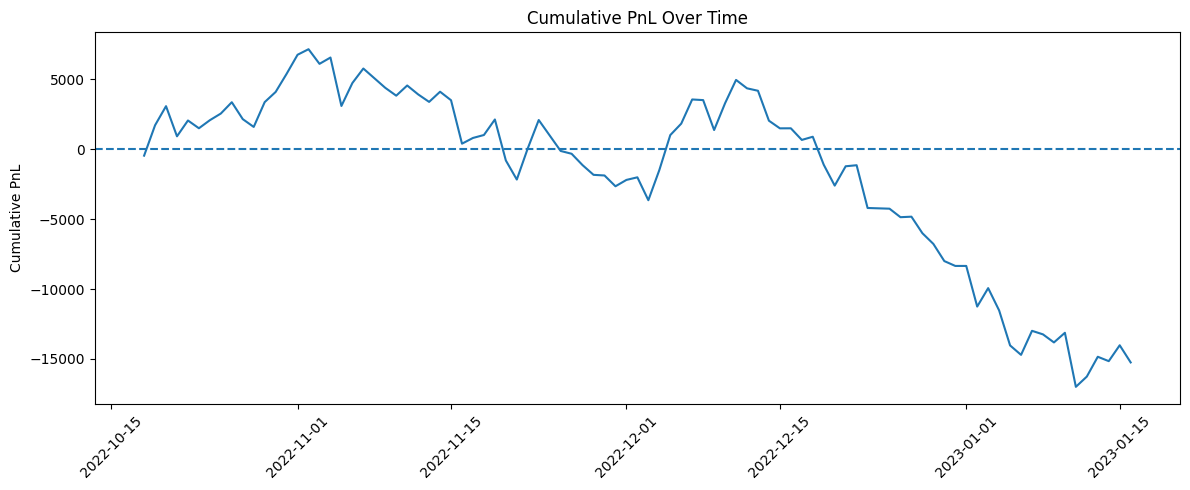

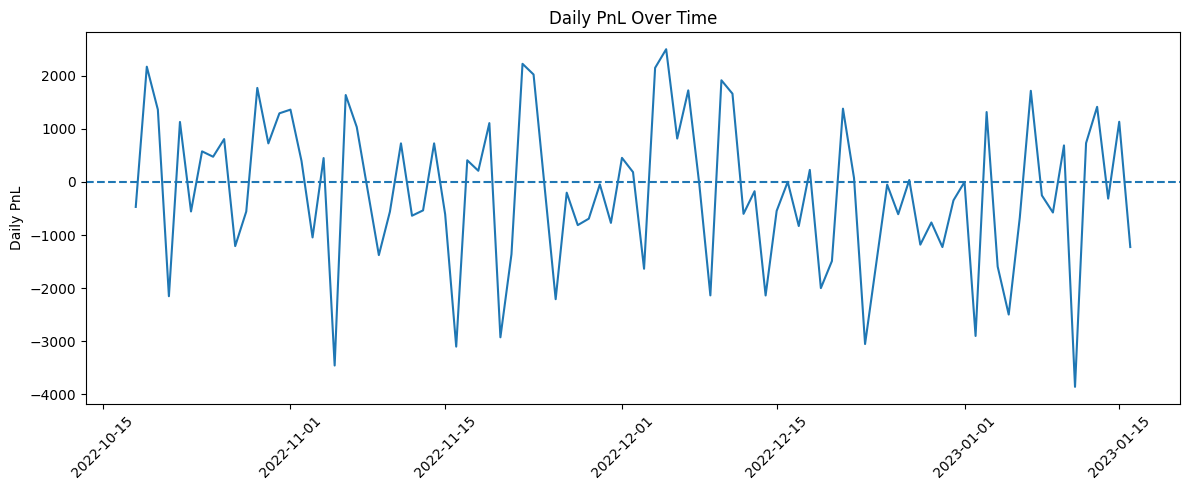

Using xgb_backtest_df


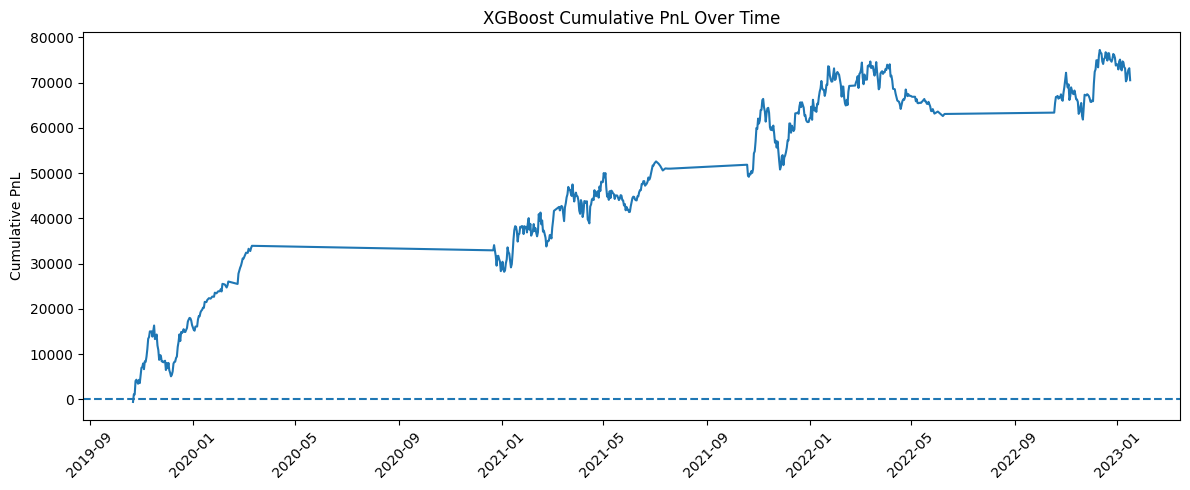

In [ ]:
import matplotlib.pyplot as plt

if 'final_results_df' in globals():
    pnl_df = final_results_df.copy()
    print("Using final_results_df")
elif 'xgb_backtest_df' in globals():
    pnl_df = xgb_backtest_df.copy()
    print("Using xgb_backtest_df")
else:
    raise ValueError("Neither final_results_df nor xgb_backtest_df exists.")

if 'PNL_XGB' in pnl_df.columns:
    pnl_df['PnL'] = pnl_df['PNL_XGB']
elif 'PNL' not in pnl_df.columns and 'PnL' not in pnl_df.columns:
    raise ValueError("No PnL column found.")

if 'PnL' not in pnl_df.columns:
    pnl_df['PnL'] = pnl_df['PNL']

pnl_df['GAME_DATE'] = pd.to_datetime(pnl_df['GAME_DATE'])
pnl_df = pnl_df.sort_values('GAME_DATE').reset_index(drop=True)

daily_pnl = (
    pnl_df.groupby('GAME_DATE', as_index=False)['PnL']
    .sum()
    .sort_values('GAME_DATE')
)
daily_pnl['CUM_PNL'] = daily_pnl['PnL'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(daily_pnl['GAME_DATE'], daily_pnl['CUM_PNL'])
plt.axhline(0, linestyle='--')
plt.xticks(rotation=45)
plt.ylabel('Cumulative PnL')
plt.title('Cumulative PnL Over Time')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(daily_pnl['GAME_DATE'], daily_pnl['PnL'])
plt.axhline(0, linestyle='--')
plt.xticks(rotation=45)
plt.ylabel('Daily PnL')
plt.title('Daily PnL Over Time')
plt.tight_layout()
plt.show()

if 'xgb_backtest_df' in globals():
    xgb_pnl_df = xgb_backtest_df.copy()
    print("Using xgb_backtest_df")
elif 'final_results_df' in globals():
    xgb_pnl_df = final_results_df.copy()
    print("Using final_results_df")
else:
    raise ValueError("Neither xgb_backtest_df nor final_results_df exists.")

if 'PNL_XGB' in xgb_pnl_df.columns:
    xgb_pnl_df['PnL'] = xgb_pnl_df['PNL_XGB']
elif 'PnL' in xgb_pnl_df.columns:
    xgb_pnl_df['PnL'] = xgb_pnl_df['PnL']
elif 'PNL' in xgb_pnl_df.columns:
    xgb_pnl_df['PnL'] = xgb_pnl_df['PNL']
else:
    raise ValueError("No XGBoost PnL column found.")

xgb_pnl_df['GAME_DATE'] = pd.to_datetime(xgb_pnl_df['GAME_DATE'])
xgb_pnl_df = xgb_pnl_df.sort_values('GAME_DATE').reset_index(drop=True)

daily_xgb_pnl = (
    xgb_pnl_df.groupby('GAME_DATE', as_index=False)['PnL']
    .sum()
    .sort_values('GAME_DATE')
)
daily_xgb_pnl['CUM_PNL'] = daily_xgb_pnl['PnL'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(daily_xgb_pnl['GAME_DATE'], daily_xgb_pnl['CUM_PNL'])
plt.axhline(0, linestyle='--')
plt.xticks(rotation=45)
plt.ylabel('Cumulative PnL')
plt.title('XGBoost Cumulative PnL Over Time')
plt.tight_layout()
plt.show()